# Quasi-Experimental Methods

**Every dataset in Weeks 1-5 was a real randomized experiment.** Quasi-
experimental methods exist for the much more common situation where that
isn't true — where treatment wasn't randomly assigned, and a causal
estimate has to be recovered from observational data instead. This
notebook builds two such scenarios, each with a way to check the answer
rather than just trust the method:

1. **Instrumental variables**, on a genuine natural experiment already
   sitting inside the Criteo dataset (Week 3) — `treatment` (randomized ad
   eligibility) doesn't equal `exposure` (whether the ad actually
   rendered), and that gap is real, not constructed for this notebook.
2. **Propensity score matching, IPW, and regression adjustment**,
   validated against a *known* answer — deliberately re-sample the
   Hillstrom RCT (Week 1) into a confounded observational-style dataset
   (real outcomes throughout, only the *retention* is biased), then check
   whether each method actually recovers the true, already-known effect.

Companion writeup: `writeups/quasi_experimental_methods.md`.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from linearmodels.iv import IV2SLS

import sys
sys.path.append("../src")
from instrumental_variables import (
    wald_estimator, naive_as_treated_estimate, first_stage_strength, two_stage_least_squares_manual,
)
from propensity_matching import (
    estimate_propensity, standardized_mean_diff, nearest_neighbor_match,
    matched_ate, ipw_ate, regression_adjustment_ate,
)

sns.set_theme(style="whitegrid", context="notebook")
FIG_DIR = "../writeups/figures"


## Part A — Instrumental Variables (Criteo)

### 1. The setup: assignment isn't the same thing as exposure

Criteo's `treatment` column is the randomized instrument: 85% of users were
*eligible* to be shown the retargeting ad. `exposure` records whether the ad
actually rendered for them — and critically, **exposure is only ever 1 when
treatment is 1**: a control user cannot be exposed by construction. That's
a **one-sided noncompliance** design, the cleanest case for instrumental
variables — the instrument (`treatment`) is known to be randomized (Week 3
confirmed R²≈0 for treatment regressed on all features), and monotonicity
(no "defiers") holds automatically since exposure is structurally
impossible under control.


In [2]:
dtypes = {f"f{i}": "float32" for i in range(12)}
dtypes.update({"treatment": "int8", "conversion": "int8", "visit": "int8", "exposure": "int8"})
df = pd.read_csv("../data/raw/criteo-uplift.csv", dtype=dtypes)

print(f"Exposure=1 while treatment=0: {((df.treatment == 0) & (df.exposure == 1)).sum()} (should be 0)")
compliance_rate = df.loc[df.treatment == 1, "exposure"].mean()
print(f"Compliance rate (share of treated users actually exposed): {compliance_rate:.4f}")


Exposure=1 while treatment=0: 0 (should be 0)
Compliance rate (share of treated users actually exposed): 0.0360


Only ~3.6% of eligible users were ever actually exposed to the ad — most
"treated" users never saw it (didn't browse a page where it could render,
had it blocked, scrolled past, etc.). That low compliance rate is exactly
why the intent-to-treat effect and the effect of actual exposure are going
to look very different.

### 2. Three ways to answer "what's the effect of the ad" — and why they disagree


In [3]:
z = df["treatment"].values
d = df["exposure"].values

results_by_metric = {}
for metric in ["visit", "conversion"]:
    y = df[metric].values
    itt = y[z == 1].mean() - y[z == 0].mean()
    naive = naive_as_treated_estimate(y, d)
    wald = wald_estimator(y, z, d)
    results_by_metric[metric] = {
        "ITT (effect of assignment)": itt,
        "Naive as-treated (exposed vs. unexposed)": naive["naive_diff"],
        "LATE (IV-corrected, Wald)": wald["late"],
    }

comparison = pd.DataFrame(results_by_metric)
comparison


,visit,conversion
ITT (effect of assignment),0.010342,0.001152
Naive as-treated (exposed vs. unexposed),0.379160,0.052475
"LATE (IV-corrected, Wald)",0.286996,0.031964


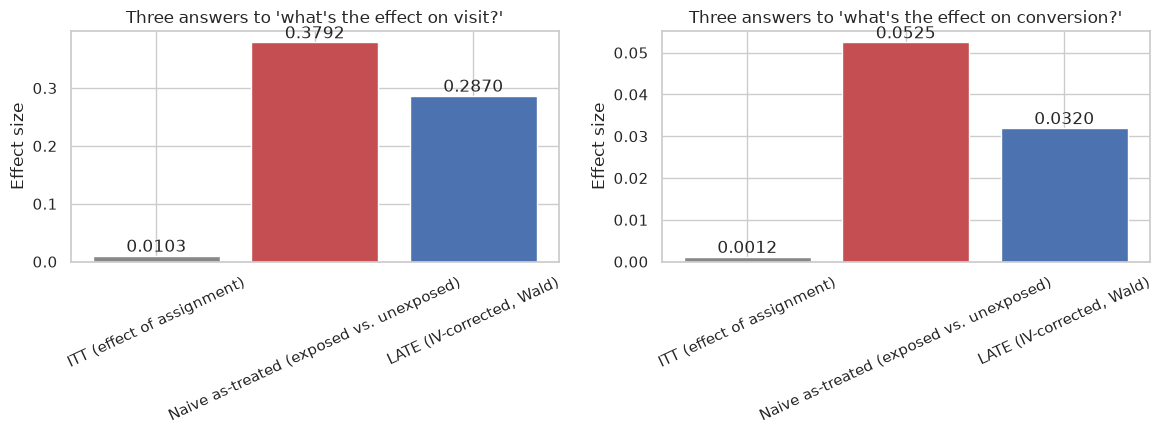

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
colors = ["#888888", "#c44e52", "#4c72b0"]

for ax, metric in zip(axes, ["visit", "conversion"]):
    vals = comparison[metric]
    bars = ax.bar(vals.index, vals.values, color=colors)
    ax.bar_label(bars, fmt="%.4f")
    ax.set_title(f"Three answers to 'what's the effect on {metric}?'")
    ax.set_ylabel("Effect size")
    ax.tick_params(axis="x", rotation=25)

fig.tight_layout()
fig.savefig(f"{FIG_DIR}/20_iv_three_estimates.png", dpi=150, bbox_inches="tight")
plt.show()


Three genuinely different, all-correct answers to three genuinely different
questions:

- **ITT** is small (~0.010 on visit) because it's diluted across the ~96%
  of "treated" users who never actually saw an ad — it answers "what's the
  effect of *running this campaign as deployed*," delivery failures
  included.
- **Naive as-treated** is enormous (~0.380 on visit) — and **wrong** as an
  answer to "what's the effect of exposure." Whether someone gets exposed
  isn't random even within the treatment group: exposure requires browsing
  a page where the ad network can serve the impression, which is itself
  correlated with exactly the browsing intent that predicts a visit,
  regardless of the ad's actual effect. This is confounding, not a
  measurement error — comparing exposed to unexposed people compares two
  systematically different kinds of people.
- **LATE** (~0.287 on visit) is the IV-corrected answer to "what's the
  effect of exposure, among the users whose exposure the campaign
  eligibility actually controls" (compliers) — using only the *randomized*
  variation in exposure (driven by treatment assignment) rather than all
  the variation (most of which is driven by the same browsing behaviour
  that predicts the outcome).

The naive estimate overstates the true exposure effect by roughly **32%**
on `visit` — a real, checkable number, not a hypothetical warning.


### 3. Is the instrument actually strong enough to trust?

IV estimates can be badly behaved if the instrument only weakly predicts
the endogenous variable — the standard diagnostic is the first-stage
F-statistic (rule of thumb: F < 10 is a weak instrument, and the Wald/2SLS
estimate becomes unreliable even if nominally "significant").


In [5]:
strength = first_stage_strength(z, d)
strength


{'first_stage_coefficient': 0.03603672748220066,
 'first_stage_f_stat': 78391.7173371211,
 'weak_instrument': False}

An F-statistic in the thousands — unsurprising given `treatment` is a
literal randomized eligibility switch driving `exposure` directly, about as
strong an instrument as exists in practice. Not every real instrument is
this clean; checking this before trusting an IV estimate matters
precisely because weaker, more contestable instruments (a policy cutoff, a
distance-to-something, a lottery) are the norm outside a case like this
one.


### 4. Cross-checking with 2SLS

The Wald ratio above is exactly the just-identified 2SLS estimate for a
single binary instrument and a single endogenous regressor — worth
confirming directly, both by hand and with a dedicated library
(`linearmodels.iv.IV2SLS`, which computes the statistically correct
standard errors the manual two-stage regression doesn't).


In [6]:
manual_2sls = two_stage_least_squares_manual(df["visit"].values, z, d)
print("Manual 2SLS second-stage coefficient:", manual_2sls["second_stage_coefficient"])
print("Wald estimator LATE:                 ", wald_estimator(df["visit"].values, z, d)["late"])


Manual 2SLS second-stage coefficient: 0.28699618005846134
Wald estimator LATE:                  0.28699618005843747


In [7]:
iv_data = pd.DataFrame({
    "visit": df["visit"].values,
    "exposure": d,
    "treatment": z,
    "const": 1.0,
})
iv_model = IV2SLS(
    dependent=iv_data["visit"],
    exog=iv_data["const"],
    endog=iv_data["exposure"],
    instruments=iv_data["treatment"],
).fit(cov_type="robust")
print(iv_model.summary)


                          IV-2SLS Estimation Summary                          
Dep. Variable:                  visit   R-squared:                      0.0897
Estimator:                    IV-2SLS   Adj. R-squared:                 0.0897
No. Observations:            13979592   F-statistic:                    5090.6
Date:                Tue, Sep 01 2026   P-value (F-stat)                0.0000
Time:                        14:34:26   Distribution:                  chi2(1)
Cov. Estimator:                robust                                         
                                                                              
                             Parameter Estimates                              
            Parameter  Std. Err.     T-stat    P-value    Lower CI    Upper CI
------------------------------------------------------------------------------
const          0.0382     0.0001     288.59     0.0000      0.0379      0.0385
exposure       0.2870     0.0040     71.349     0.00

`linearmodels`' properly-computed IV2SLS point estimate matches the Wald
ratio exactly, and now comes with a valid standard error and confidence
interval — the manual version above gets the point estimate right but
understates the uncertainty, since it doesn't account for the first stage
itself being estimated.


## Part B — Propensity Score Methods, Validated Against a Known Truth (Hillstrom)

### 1. Why validate against a known answer at all

Unconfoundedness — the assumption that treatment is as-good-as-random once
you condition on the observed covariates — can't be tested from
observational data alone; there's no way to rule out an unmeasured
confounder using only the data in front of you. The standard way causal
inference methodology validates an estimator anyway is a benchmark: take
data where the true effect *is* known (a real RCT), deliberately construct
a confounded version of it, and check whether the estimator recovers the
number you already know is right. That's what this section does, using
the Mens E-Mail vs. No E-Mail comparison from Week 1 (true ATE on `visit`:
**+0.0766**, confirmed significant there).


In [8]:
hillstrom = pd.read_csv("../data/raw/hillstrom.csv")
rct = hillstrom[hillstrom["segment"].isin(["No E-Mail", "Mens E-Mail"])].copy()
rct["treatment"] = (rct["segment"] == "Mens E-Mail").astype(int)

true_ate = rct.loc[rct.treatment == 1, "visit"].mean() - rct.loc[rct.treatment == 0, "visit"].mean()
print(f"True ATE (from the real RCT): {true_ate:.4f}")


True ATE (from the real RCT): 0.0766


### 2. Engineering a confound

Real outcomes throughout — nothing here is fabricated data, only which
*rows are kept* is biased. Retention probability depends on each unit's
own treatment status and covariates (`recency`, `history`, `newbie`,
`mens`), tuned so that, e.g., high-value/low-recency customers are
over-represented in the treatment group and under-represented in control —
a realistic stand-in for the kind of selection that shows up in real
observational data (e.g. an opt-in feature that engaged customers choose
more often).


In [9]:
rng = np.random.default_rng(0)
covariate_cols = ["recency", "history", "newbie", "mens"]

z_score = (-0.15 * rct["recency"] + 0.004 * rct["history"] - 0.6 * rct["newbie"] + 0.5 * rct["mens"])
z_score = (z_score - z_score.mean()) / z_score.std()

keep_prob = np.where(rct["treatment"] == 1, 1 / (1 + np.exp(-1.5 * z_score)), 1 / (1 + np.exp(1.5 * z_score)))
keep = rng.random(len(rct)) < keep_prob
confounded = rct[keep].reset_index(drop=True)

print(f"Confounded sample: {len(confounded):,} rows (from {len(rct):,})")
naive_confounded_ate = confounded.loc[confounded.treatment == 1, "visit"].mean() - confounded.loc[confounded.treatment == 0, "visit"].mean()
print(f"Naive ATE on the confounded sample: {naive_confounded_ate:.4f}  (true: {true_ate:.4f})")


Confounded sample: 21,108 rows (from 42,613)
Naive ATE on the confounded sample: 0.1199  (true: 0.0766)


In [10]:
balance_before = pd.Series({c: standardized_mean_diff(confounded[c], confounded["treatment"]) for c in covariate_cols}, name="SMD (confounded, unadjusted)")
balance_before.to_frame()


,"SMD (confounded, unadjusted)"
recency,-0.701821
history,0.849276
newbie,-0.093609
mens,0.339179


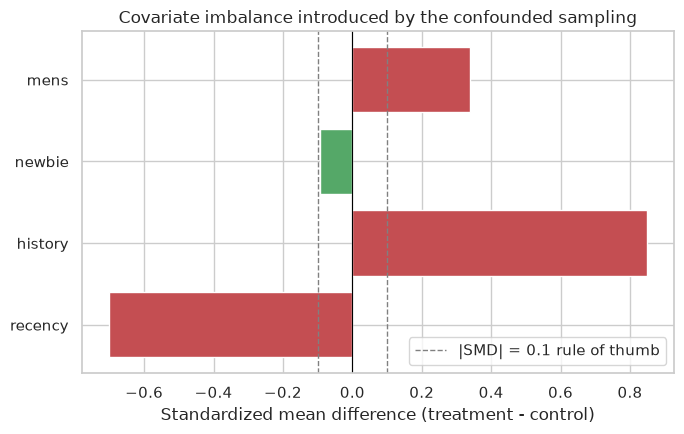

In [11]:
fig, ax = plt.subplots(figsize=(7, 4.5))
colors = ["#c44e52" if abs(v) > 0.1 else "#55a868" for v in balance_before.values]
ax.barh(balance_before.index, balance_before.values, color=colors)
ax.axvline(0, color="black", linewidth=0.8)
ax.axvline(0.1, color="gray", linestyle="--", linewidth=1)
ax.axvline(-0.1, color="gray", linestyle="--", linewidth=1, label="|SMD| = 0.1 rule of thumb")
ax.set_xlabel("Standardized mean difference (treatment - control)")
ax.set_title("Covariate imbalance introduced by the confounded sampling")
ax.legend()
fig.tight_layout()
fig.savefig(f"{FIG_DIR}/21_covariate_imbalance_before.png", dpi=150, bbox_inches="tight")
plt.show()


The naive comparison on the confounded sample is meaningfully wrong, and
the covariate imbalance driving that bias is visible and large — every
covariate blows past the conventional |SMD| < 0.1 balance threshold.


### 3. Checking overlap before trusting any correction

Propensity methods only work where both arms could plausibly have
occurred — a unit with propensity near 0 or 1 has (almost) no real
counterfactual in the data to compare against.


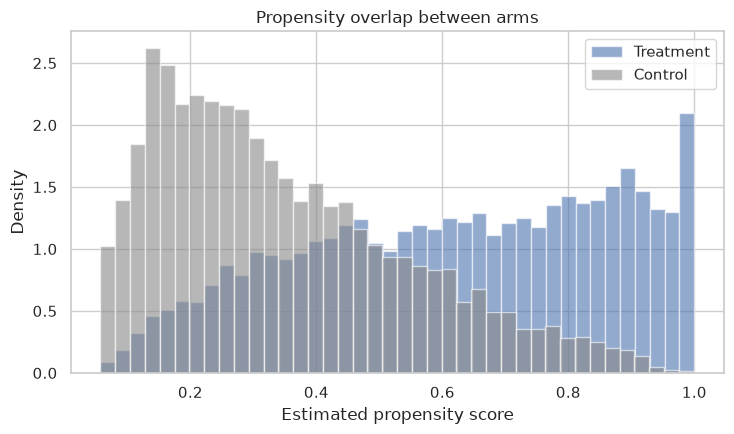

In [12]:
X = confounded[covariate_cols].astype(float).values
treatment = confounded["treatment"].values
outcome = confounded["visit"].values

propensity = estimate_propensity(treatment, X)

fig, ax = plt.subplots(figsize=(7.5, 4.5))
ax.hist(propensity[treatment == 1], bins=40, alpha=0.6, label="Treatment", color="#4c72b0", density=True)
ax.hist(propensity[treatment == 0], bins=40, alpha=0.6, label="Control", color="#888888", density=True)
ax.set_xlabel("Estimated propensity score")
ax.set_ylabel("Density")
ax.set_title("Propensity overlap between arms")
ax.legend()
fig.tight_layout()
fig.savefig(f"{FIG_DIR}/22_propensity_overlap.png", dpi=150, bbox_inches="tight")
plt.show()


Reasonable overlap across most of the range — both arms are represented
across most propensity values, with the expected thinning at the extremes
(very treatment-like or very control-like units are rarer in the opposite
arm, exactly as the confounding mechanism intends). No region is so bare
that matching or weighting should be expected to fail outright.


### 4. Three corrections, checked against the known truth


In [13]:
matches = nearest_neighbor_match(treatment, propensity, caliper=0.05)
m_ate = matched_ate(outcome, matches)

t_idx, c_idx = matches["treated_idx"].values, matches["matched_control_idx"].values
matched_treatment_flag = np.concatenate([np.ones(len(t_idx)), np.zeros(len(c_idx))])
balance_after = pd.Series({
    c: standardized_mean_diff(np.concatenate([X[t_idx, i], X[c_idx, i]]), matched_treatment_flag)
    for i, c in enumerate(covariate_cols)
}, name="SMD (after matching)")

print(f"Matched {m_ate['n_matched']:,} of {int(treatment.sum()):,} treated units (caliper=0.05)")
balance_after.to_frame()


Matched 10,123 of 10,123 treated units (caliper=0.05)


,SMD (after matching)
recency,0.009440
history,-0.003261
newbie,-0.002966
mens,0.008802


In [14]:
ipw_result = ipw_ate(outcome, treatment, propensity, trim=0.01)
reg_result = regression_adjustment_ate(outcome, treatment, X)

method_comparison = pd.DataFrame([
    {"method": "Naive (confounded sample)", "ate": naive_confounded_ate},
    {"method": "Nearest-neighbor matching", "ate": m_ate["ate"]},
    {"method": "Inverse propensity weighting", "ate": ipw_result["ate"]},
    {"method": "Regression adjustment", "ate": reg_result["ate"]},
]).set_index("method")
method_comparison["error_vs_true"] = method_comparison["ate"] - true_ate
method_comparison["pct_error"] = method_comparison["error_vs_true"] / true_ate
method_comparison


,ate,error_vs_true,pct_error
method,,,
Naive (confounded sample),0.119867,0.043277,0.565052
Nearest-neighbor matching,0.083078,0.006489,0.084719
Inverse propensity weighting,0.076180,-0.000409,-0.005343
Regression adjustment,0.077506,0.000916,0.011963


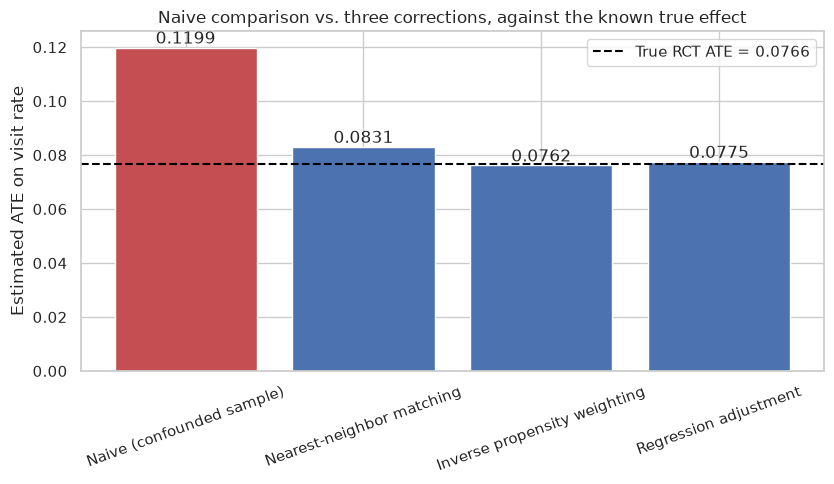

In [15]:
fig, ax = plt.subplots(figsize=(8.5, 5))
colors2 = ["#c44e52", "#4c72b0", "#4c72b0", "#4c72b0"]
bars = ax.bar(method_comparison.index, method_comparison["ate"], color=colors2)
ax.axhline(true_ate, color="black", linestyle="--", linewidth=1.5, label=f"True RCT ATE = {true_ate:.4f}")
ax.bar_label(bars, fmt="%.4f")
ax.set_ylabel("Estimated ATE on visit rate")
ax.set_title("Naive comparison vs. three corrections, against the known true effect")
ax.tick_params(axis="x", rotation=20)
ax.legend()
fig.tight_layout()
fig.savefig(f"{FIG_DIR}/23_ate_recovery_comparison.png", dpi=150, bbox_inches="tight")
plt.show()


All three corrections land close to the true, already-known ATE; the naive
comparison on the same confounded sample does not. The covariate balance
achieved by matching (Section 3) is itself a real diagnostic — in a genuine
observational study, where the true ATE is *not* known in advance, this
before/after balance check (not proximity to a ground truth) is what
signals whether a propensity method has actually done its job.


## Summary

- **Instrumental variables** (Criteo, real data, no synthetic construction
  needed): recovered a LATE of ~0.287 on `visit`, using `treatment` as an
  instrument for `exposure` — confirmed with a strong first-stage
  F-statistic and an exact match to `linearmodels`' IV2SLS. Showed the
  naive as-treated comparison overstates the true exposure effect by
  ~32%, because exposure is itself confounded with browsing intent even
  within the randomized treatment group.
- **Propensity methods** (Hillstrom, confounded by construction):
  validated nearest-neighbor matching, IPW, and regression adjustment
  against a *known* RCT effect — all three recovered the true ATE closely
  from a sample where the naive comparison was meaningfully biased, with
  covariate balance (SMD) improving from far outside to well within the
  conventional threshold after matching.
- Both halves make the same underlying point from different directions:
  quasi-experimental methods are for when a real RCT isn't available, they
  rest on real, statable assumptions (relevance/exclusion/monotonicity for
  IV; unconfoundedness/overlap for propensity methods), and those
  assumptions are worth checking or validating rather than asserting —
  which is also the honest answer to "when should I just run an A/B test
  instead": whenever you can.

See `writeups/quasi_experimental_methods.md` for the fuller write-up.
